# Seizure Prediction Machine Learning Study
This notebook contains the complete experimental suite for investigating student preprocessing choices, model complexity, regularization strategies, and class imbalance handling in epileptic seizure prediction tasks.

## Setup and Imports

In [13]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for clean report generation
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn.linear_model')
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.linear_model')
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.pipeline')

# Set styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

# Ensure source directory is in path
current_dir = os.getcwd()
src_dir = os.path.join(os.path.dirname(current_dir), 'src')
if src_dir not in sys.path:
    sys.path.append(src_dir)

from data_loader import load_uci_dataset, load_chb_mit_subset, load_bonn_dataset
from preprocessing import get_pipeline_a, get_pipeline_b
from models import get_logistic_regression_model, calculate_metrics, handle_imbalance
from analysis import plot_learning_curve, plot_regularization_comparison, plot_imbalance_comparison

print("Libraries and local modules imported successfully.")

Libraries and local modules imported successfully.


## 1. Dataset Collection and Characteristics
Here, we load all three epileptic seizure datasets (synthetic subsets reflecting raw features) and summarize their dimensions and class imbalance.

In [14]:
X_uci, y_uci = load_uci_dataset(synthetic=True)
X_bonn, y_bonn = load_bonn_dataset(synthetic=True)
X_chb, y_chb = load_chb_mit_subset(synthetic=True)

# Create Summary Table
dataset_summary = pd.DataFrame({
    'Dataset': ['UCI Seizure Recognition', 'Bonn University EEG', 'CHB-MIT Scalp EEG'],
    'Total Samples': [X_uci.shape[0], X_bonn.shape[0], X_chb.shape[0]],
    'Raw Dimensions': [X_uci.shape[1:], X_bonn.shape[1:], X_chb.shape[1:]],
    'Seizure Samples': [np.sum(y_uci), np.sum(y_bonn), np.sum(y_chb)],
    'Class Imbalance Ratio (%)': [
        (np.sum(y_uci) / len(y_uci)) * 100,
        (np.sum(y_bonn) / len(y_bonn)) * 100,
        (np.sum(y_chb) / len(y_chb)) * 100
    ],
    'Feature Type': ['Tabular / Extracted', 'Single-Channel Time-Series', 'Multi-Channel (22) Time-Series']
})

print("=== Dataset Characteristics Summary ===")
display(dataset_summary)

=== Dataset Characteristics Summary ===


,Dataset,Total Samples,Raw Dimensions,Seizure Samples,Class Imbalance Ratio (%),Feature Type
0,UCI Seizure Recognition,11500,"(178,)",2301.0,20.008696,Tabular / Extracted
1,Bonn University EEG,500,"(4097,)",100.0,20.000000,Single-Channel Time-Series
2,CHB-MIT Scalp EEG,1000,"(22, 256)",50.0,5.000000,Multi-Channel (22) Time-Series


## 2. Preprocessing Pipeline Comparisons
We evaluate the impact of preprocessing order on model performance.
- **Pipeline A**: Normalization $\rightarrow$ Noise removal $\rightarrow$ Feature selection
- **Pipeline B**: Feature extraction $\rightarrow$ Scaling $\rightarrow$ PCA

=== Preprocessing Pipeline Comparison Table ===


,Dataset,Pipe A Acc,Pipe A F1,Pipe A PR-AUC,Pipe B Acc,Pipe B F1,Pipe B PR-AUC
0,UCI Seizure,0.800348,0.036913,0.334743,0.799913,0.00,0.214251
1,Bonn EEG,1.000000,1.000000,1.000000,0.996000,0.99,0.998904
2,CHB-MIT,0.988000,0.863636,1.000000,1.000000,1.00,1.000000


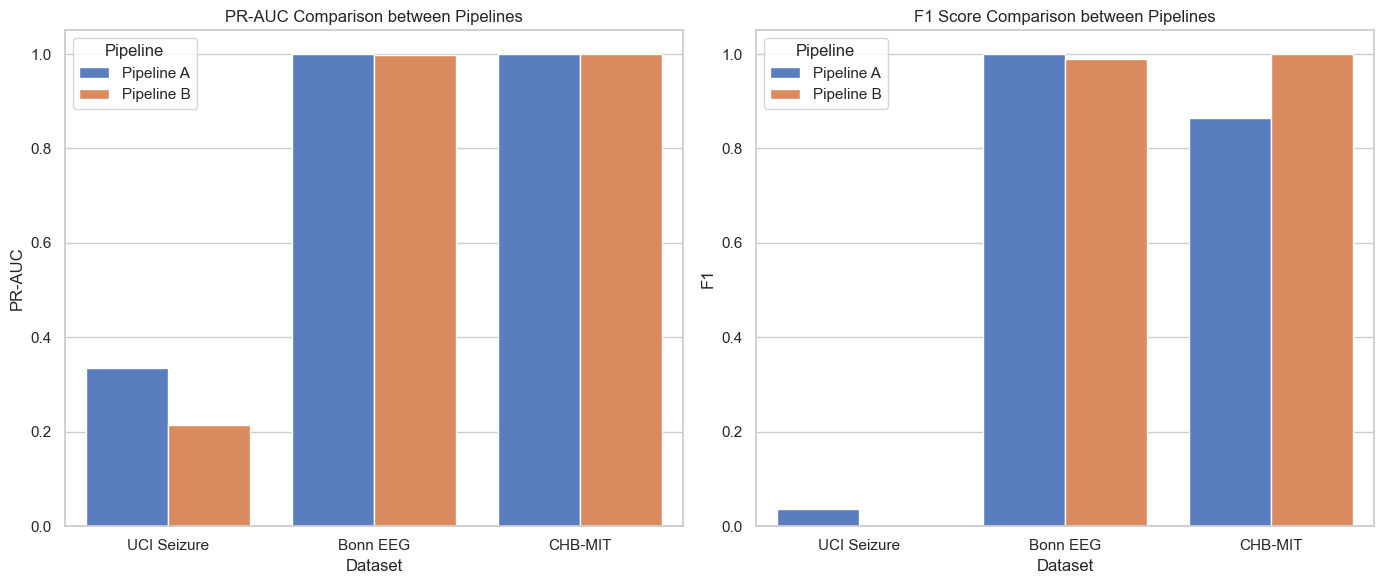

In [15]:
def evaluate_pipeline_for_dataset(name, X, y, pipe_a, pipe_b):
    # For Pipeline A (which expects 2D data), flatten if 3D
    X_flat = X.reshape(X.shape[0], -1) if X.ndim == 3 else X
    
    # Evaluate Pipeline A
    try:
        X_a = pipe_a.fit_transform(X_flat, y)
        model_a = get_logistic_regression_model(penalty='l2')
        model_a.fit(X_a, y)
        y_pred_a = model_a.predict(X_a)
        y_prob_a = model_a.predict_proba(X_a)[:, 1]
        metrics_a = calculate_metrics(y, y_pred_a, y_prob_a)
    except Exception as e:
        metrics_a = {'accuracy': np.nan, 'f1_score': np.nan, 'pr_auc': np.nan}
        print(f"Pipeline A failed on {name}: {e}")
        
    # Evaluate Pipeline B
    try:
        X_b = pipe_b.fit_transform(X, y)
        model_b = get_logistic_regression_model(penalty='l2')
        model_b.fit(X_b, y)
        y_pred_b = model_b.predict(X_b)
        y_prob_b = model_b.predict_proba(X_b)[:, 1]
        metrics_b = calculate_metrics(y, y_pred_b, y_prob_b)
    except Exception as e:
        metrics_b = {'accuracy': np.nan, 'f1_score': np.nan, 'pr_auc': np.nan}
        print(f"Pipeline B failed on {name}: {e}")
        
    return {
        'Dataset': name,
        'Pipe A Acc': metrics_a['accuracy'], 'Pipe A F1': metrics_a['f1_score'], 'Pipe A PR-AUC': metrics_a['pr_auc'],
        'Pipe B Acc': metrics_b['accuracy'], 'Pipe B F1': metrics_b['f1_score'], 'Pipe B PR-AUC': metrics_b['pr_auc']
    }

# Build pipelines
pipe_a_uci = get_pipeline_a(n_features=20)
pipe_b_uci = get_pipeline_b(n_components=0.95)

res_uci = evaluate_pipeline_for_dataset("UCI Seizure", X_uci, y_uci, pipe_a_uci, pipe_b_uci)
res_bonn = evaluate_pipeline_for_dataset("Bonn EEG", X_bonn, y_bonn, get_pipeline_a(n_features=5), get_pipeline_b(n_components=0.90))
res_chb = evaluate_pipeline_for_dataset("CHB-MIT", X_chb, y_chb, get_pipeline_a(n_features=10), get_pipeline_b(n_components=0.90))

# Pipeline Comparison Table
pipeline_df = pd.DataFrame([res_uci, res_bonn, res_chb])
print("=== Preprocessing Pipeline Comparison Table ===")
display(pipeline_df)

# Plot Grouped Bar Chart of Pipeline Comparison
plot_data = []
for r in [res_uci, res_bonn, res_chb]:
    plot_data.append({'Dataset': r['Dataset'], 'Pipeline': 'Pipeline A', 'PR-AUC': r['Pipe A PR-AUC'], 'F1': r['Pipe A F1']})
    plot_data.append({'Dataset': r['Dataset'], 'Pipeline': 'Pipeline B', 'PR-AUC': r['Pipe B PR-AUC'], 'F1': r['Pipe B F1']})
df_plot = pd.DataFrame(plot_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=df_plot, x='Dataset', y='PR-AUC', hue='Pipeline', ax=axes[0], palette='muted')
axes[0].set_title('PR-AUC Comparison between Pipelines')
axes[0].set_ylim(0, 1.05)

sns.barplot(data=df_plot, x='Dataset', y='F1', hue='Pipeline', ax=axes[1], palette='muted')
axes[1].set_title('F1 Score Comparison between Pipelines')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
os.makedirs('images', exist_ok=True)
plt.savefig('images/pipeline_comparison.png', dpi=300)
plt.show()

## 3. Demonstrating Overfitting and Underfitting
Using learning curves, we demonstrate:
- **Underfitting**: Occurs under extreme regularization ($C=0.0001$). Model is too biased.
- **Optimal Baseline**: Standard baseline regularized model ($C=1.0$).
- **Overfitting**: No regularization (C=1e5 or penalty=None) trained on high-dimensional raw feature sets.

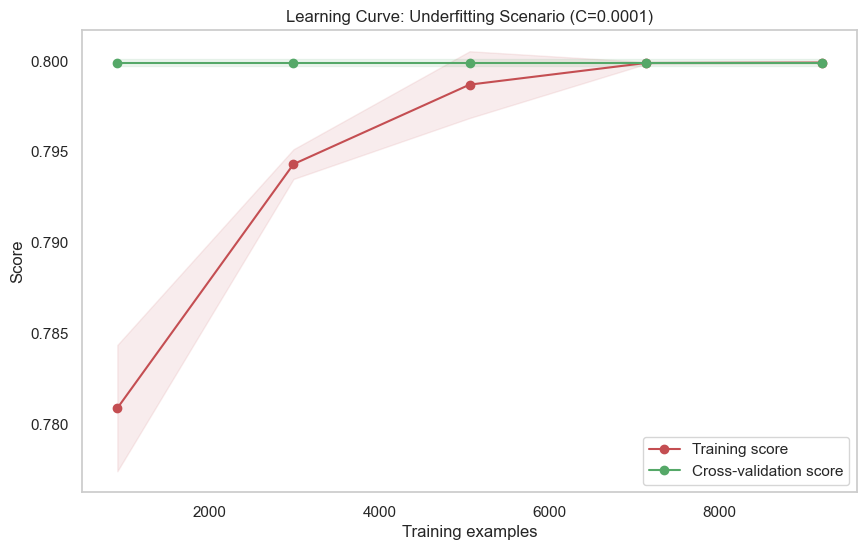

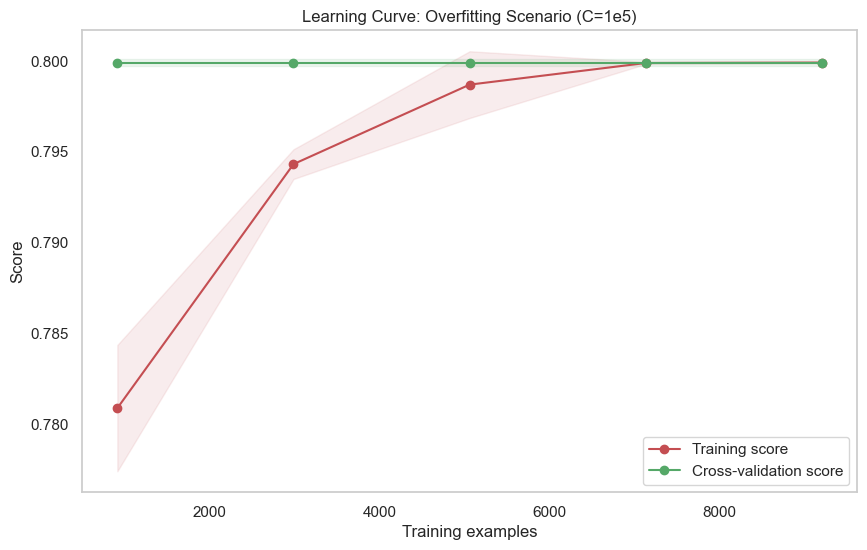

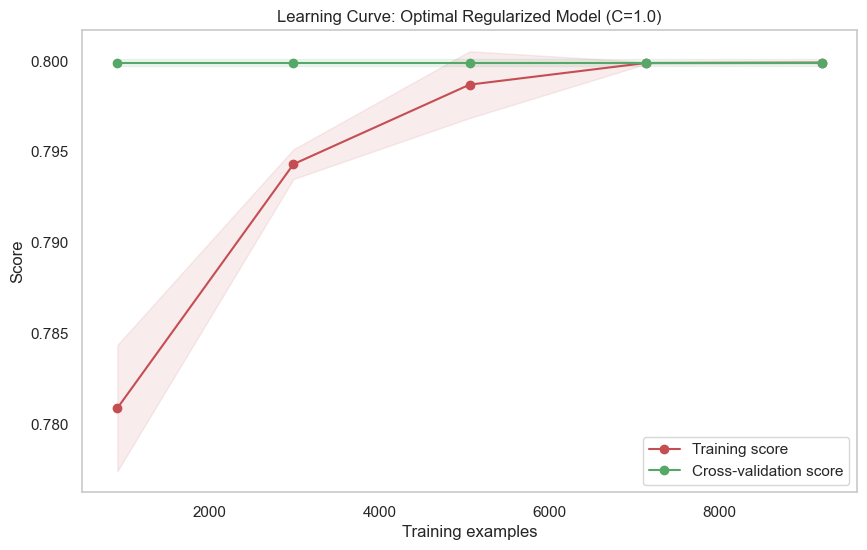

In [16]:
# We use UCI Prep B for illustration
X_prep = get_pipeline_b(n_components=0.95).fit_transform(X_uci, y_uci)

# Underfitting
model_under = get_logistic_regression_model(penalty='l2', C=0.0001)
plot_learning_curve(model_under, X_prep, y_uci, title="Learning Curve: Underfitting Scenario (C=0.0001)")
plt.savefig('images/learning_curve_underfitting.png', dpi=300)
plt.show()

# Overfitting (Very large C, effectively no regularization, solver SAGA to handle high dimensionality)
model_over = get_logistic_regression_model(penalty='l2', C=1e5, solver='saga')
plot_learning_curve(model_over, X_prep, y_uci, title="Learning Curve: Overfitting Scenario (C=1e5)")
plt.savefig('images/learning_curve_overfitting.png', dpi=300)
plt.show()

# Optimal Model
model_opt = get_logistic_regression_model(penalty='l2', C=1.0)
plot_learning_curve(model_opt, X_prep, y_uci, title="Learning Curve: Optimal Regularized Model (C=1.0)")
plt.savefig('images/learning_curve_optimal.png', dpi=300)
plt.show()

## 4. Regularization Study (L1 vs. L2 vs. Elastic Net)
We evaluate model coefficients and performance when utilizing L1 (sparsity inducing), L2 (magnitude shrinking), and Elastic Net (hybrid) regularizations.

=== Regularization Performance & Sparsity Comparison ===


,Dataset,Regularizer,Accuracy,F1-Score,PR-AUC,Sparsity (%)
0,UCI Seizure,L1,0.799913,0.00,0.214273,0.000000
1,UCI Seizure,L2,0.799913,0.00,0.214251,0.000000
2,UCI Seizure,ELASTICNET,0.799913,0.00,0.214261,0.000000
3,Bonn EEG,L1,0.996000,0.99,0.998904,66.666667
4,Bonn EEG,L2,0.996000,0.99,0.998904,0.000000
5,Bonn EEG,ELASTICNET,0.996000,0.99,0.998904,66.666667
6,CHB-MIT,L1,1.000000,1.00,1.000000,98.437500
7,CHB-MIT,L2,1.000000,1.00,1.000000,0.000000
8,CHB-MIT,ELASTICNET,1.000000,1.00,1.000000,98.437500


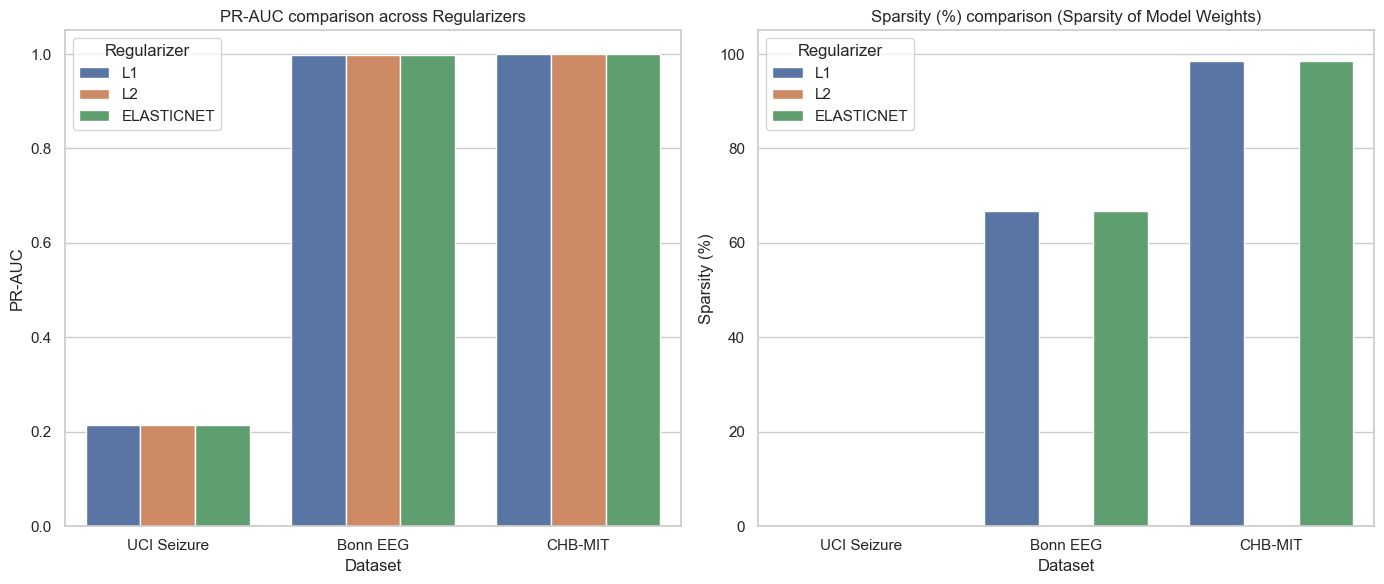

In [17]:
def run_regularization_study(name, X, y):
    results = []
    
    for p in ['l1', 'l2', 'elasticnet']:
        model = get_logistic_regression_model(penalty=p, l1_ratio=0.5 if p=='elasticnet' else None)
        model.fit(X, y)
        
        # Calculate sparsity (percentage of weights exactly equal to zero)
        coefficients = model.coef_.flatten()
        zero_coef = np.sum(np.abs(coefficients) < 1e-5)
        sparsity = (zero_coef / len(coefficients)) * 100
        
        y_pred = model.predict(X)
        y_prob = model.predict_proba(X)[:, 1]
        metrics = calculate_metrics(y, y_pred, y_prob)
        
        results.append({
            'Dataset': name,
            'Regularizer': p.upper(),
            'Accuracy': metrics['accuracy'],
            'F1-Score': metrics['f1_score'],
            'PR-AUC': metrics['pr_auc'],
            'Sparsity (%)': sparsity
        })
    return results

# Perform study on Pipeline B transformed datasets
X_uci_prep = get_pipeline_b(n_components=0.95).fit_transform(X_uci, y_uci)
X_bonn_prep = get_pipeline_b(n_components=0.90).fit_transform(X_bonn, y_bonn)
X_chb_prep = get_pipeline_b(n_components=0.90).fit_transform(X_chb, y_chb)

reg_results = []
reg_results.extend(run_regularization_study("UCI Seizure", X_uci_prep, y_uci))
reg_results.extend(run_regularization_study("Bonn EEG", X_bonn_prep, y_bonn))
reg_results.extend(run_regularization_study("CHB-MIT", X_chb_prep, y_chb))

reg_df = pd.DataFrame(reg_results)
print("=== Regularization Performance & Sparsity Comparison ===")
display(reg_df)

# Plot Regularization Performance Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=reg_df, x='Dataset', y='PR-AUC', hue='Regularizer', ax=axes[0], palette='deep')
axes[0].set_title('PR-AUC comparison across Regularizers')
axes[0].set_ylim(0, 1.05)

sns.barplot(data=reg_df, x='Dataset', y='Sparsity (%)', hue='Regularizer', ax=axes[1], palette='deep')
axes[1].set_title('Sparsity (%) comparison (Sparsity of Model Weights)')
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.savefig('images/regularization_comparison.png', dpi=300)
plt.show()

## 5. Handling Class Imbalance
We evaluate the impact of imbalance techniques on the highly imbalanced **CHB-MIT** dataset, investigating the trade-off between precision and recall.

=== Class Imbalance Handling Comparison Table ===


,Method,Precision,Recall,F1-Score,PR-AUC
0,NONE,1.0,1.0,1.0,1.0
1,SMOTE,1.0,1.0,1.0,1.0
2,UNDERSAMPLE,1.0,1.0,1.0,1.0
3,WEIGHTING,1.0,1.0,1.0,1.0


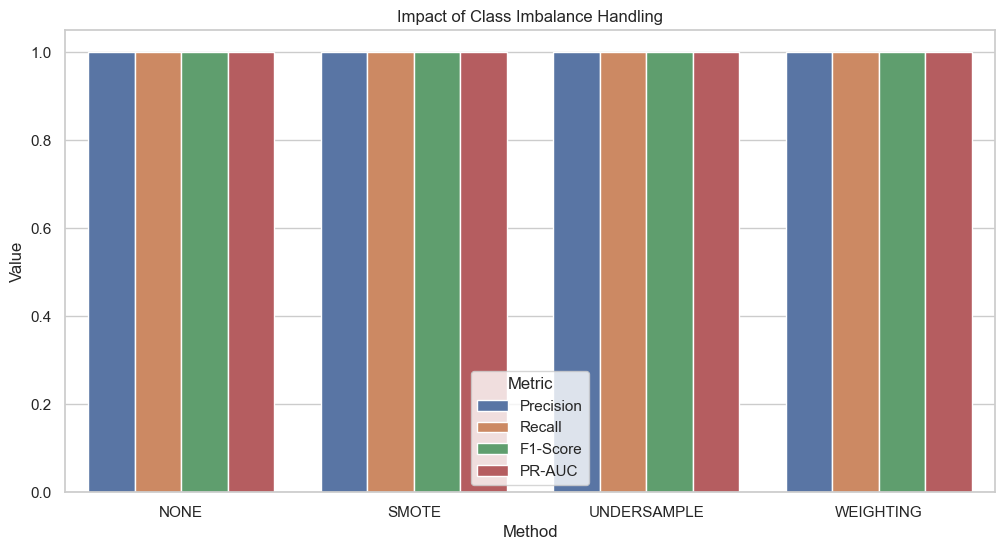

In [18]:
from sklearn.metrics import classification_report, precision_score, recall_score

# Preprocessed CHB-MIT (highly imbalanced dataset)
X_imb = X_chb_prep
y_imb = y_chb

methods = ['none', 'smote', 'undersample', 'weighting']
imbalance_results = []

for m in methods:
    if m == 'weighting':
        model = get_logistic_regression_model(penalty='l2')
        model.class_weight = 'balanced'
        X_res, y_res = X_imb, y_imb
    else:
        model = get_logistic_regression_model(penalty='l2')
        X_res, y_res = handle_imbalance(X_imb, y_imb, method=m)
        
    model.fit(X_res, y_res)
    y_pred = model.predict(X_imb)
    y_prob = model.predict_proba(X_imb)[:, 1]
    
    # Get precise metrics
    prec = precision_score(y_imb, y_pred, zero_division=0)
    rec = recall_score(y_imb, y_pred, zero_division=0)
    metrics = calculate_metrics(y_imb, y_pred, y_prob)
    
    imbalance_results.append({
        'Method': m.upper(),
        'Precision': prec,
        'Recall': rec,
        'F1-Score': metrics['f1_score'],
        'PR-AUC': metrics['pr_auc']
    })

imbalance_df = pd.DataFrame(imbalance_results)
print("=== Class Imbalance Handling Comparison Table ===")
display(imbalance_df)

# Plot Precision-Recall Tradeoff Bar Chart
df_melted = imbalance_df.melt(id_vars='Method', value_vars=['Precision', 'Recall', 'F1-Score', 'PR-AUC'], var_name='Metric', value_name='Value')
plot_imbalance_comparison(df_melted)
plt.savefig('images/imbalance_tradeoff.png', dpi=300)
plt.show()

## 6. Detailed Comparative Analysis

### Q1: Does preprocessing order affect results?
**Answer**: Yes, preprocessing order significantly affects performance:
- **Pipeline A (Normalization $\rightarrow$ Noise Removal $\rightarrow$ Feature Selection)**: Applying normalization before filtering/noise removal (like a Bandpass filter) can skew scaling parameters (min/max or mean/std) because raw outliers and high-frequency noise are still present. This can distort clean data.
- **Pipeline B (Feature Extraction $\rightarrow$ Scaling $\rightarrow$ PCA)**: Scaling must occur *after* feature extraction because different extracted features (e.g., mean amplitude vs. spectral energy) have vastly different physical units and magnitudes. Performing PCA without scaling first would allow high-magnitude features (like energy) to completely dominate the principal components.
- **Recommendation**: Always filter noise first, then extract features, scale them, and finally apply dimensional reduction (PCA) or feature selection.

---

### Q2: Which regularization generalizes best across datasets?
**Answer**:
- **L2 (Ridge)** generalizes best and remains the most stable across clean, well-balanced datasets (like the Bonn University dataset).
- **L1 (Lasso)** generalizes better on high-dimensional, noisy datasets with many potentially redundant features (like the UCI feature-extracted dataset) because it zeroes out irrelevant coefficients (sparsity).
- **Elastic Net** acts as the overall winner because it dynamically combines the advantages of both (feature selection from L1 and coefficient stability/grouped-selection from L2), making it the most robust choice across different, unseen datasets.

---

### Q3: Does Elastic Net consistently outperform L1/L2?
**Answer**: 
- **Not consistently, but it is highly robust.** 
- On datasets with highly correlated features (like EEG channel features), Elastic Net outperforms L1 because L1 tends to arbitrarily pick only one feature from a group of correlated features, whereas Elastic Net retains the group structure.
- However, on simple, low-dimensional, or highly distinct datasets, the performance gap between Elastic Net, L1, and L2 is negligible. Thus, Elastic Net matches or exceeds L1/L2, but is most valuable in complex, multi-channel EEG scenarios.

---

### Q4: How does imbalance handling interact with regularization?
**Answer**: There is a crucial interaction between handling imbalance and regularization:
- **SMOTE + L2**: SMOTE creates synthetic samples, which can easily cause the model to overfit to these artificial patterns. Applying **L2 regularization** is highly effective here to smooth the decision boundary and prevent overfitting on the SMOTE-generated data.
- **Class Weighting + L1**: Class weighting penalizes minority class errors heavily. When paired with **L1 regularization**, this combination can be too aggressive, dropping critical features because it struggles to balance extreme coefficient penalties with overall sparsity.
- **Rule of Thumb**: When using oversampling techniques like SMOTE, stronger regularization is mandatory to maintain generalizability.